# 🏋️ Notebook 03: Multimodal Model Training & Evaluation

**Objective:** Fine-tune the DenseNet-121 + Bio_ClinicalBERT fusion model on MedPix.

**Architecture:**
```
IMAGE (224×224×3) → DenseNet-121 → GAP → [1024-dim embedding]
                                                              \
         Concat [1792-dim] → Linear(512) → LayerNorm → ReLU → Linear(10)
                                                              /
TEXT (tokens × 256) → Bio_ClinicalBERT → [CLS] → [768-dim embedding]
```

**Sections:**
1. Setup model + optimizer + scheduler
2. Compute class weights for imbalance
3. Training loop with AMP (mixed precision)
4. Training curves visualization
5. Comprehensive evaluation on test set
6. Confusion matrix + AUC-ROC curves
7. Save evaluation report

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    matthews_corrcoef, roc_auc_score, roc_curve, auc
)
import torchvision.transforms as T

import config
from src.training.multimodal_predictor import MultimodalClinicalPredictor, MultimodalDataset

torch.manual_seed(config.RANDOM_SEED)
np.random.seed(config.RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
print(f'Device: {DEVICE} | AMP: {USE_AMP}')

# Check CUDA VRAM if available
if torch.cuda.is_available():
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {torch.cuda.get_device_name(0)} | VRAM: {vram_gb:.1f} GB')
    if vram_gb < 6:
        print('⚠️  Low VRAM detected (< 6 GB). Freezing DenseNet base + BERT base for speed.')
        FREEZE_BASES = True
    else:
        FREEZE_BASES = False
else:
    FREEZE_BASES = True  # CPU mode: freeze to speed up training
    print('⚠️  CPU mode — freezing base layers. Training will be slow but functional.')

Device: cuda | AMP: True
GPU: NVIDIA GeForce GTX 1650 | VRAM: 4.3 GB
⚠️  Low VRAM detected (< 6 GB). Freezing DenseNet base + BERT base for speed.


## 1️⃣ Initialize Model

In [2]:
hf_token = config.HF_TOKEN if config.HF_TOKEN != 'YOUR_HF_TOKEN_HERE' else None
tokenizer = AutoTokenizer.from_pretrained(config.TEXT_ENCODER_MODEL, token=hf_token)

model = MultimodalClinicalPredictor(
    num_classes=config.NUM_CLASSES,
    text_model_name=config.TEXT_ENCODER_MODEL,
    hidden_dim=config.FUSION_HIDDEN_DIM,
    dropout_rate=config.DROPOUT_RATE,
    freeze_image_base=FREEZE_BASES,
    freeze_text_base=FREEZE_BASES,
).to(DEVICE)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total parameters:     116,188,298
Trainable parameters: 17,850,634 (15.4%)


## 2️⃣ DataLoaders + Class Weights

In [3]:
# Load processed splits
df_train = pd.read_csv('../data/processed/train.csv')
df_val   = pd.read_csv('../data/processed/val.csv')
df_test  = pd.read_csv('../data/processed/test.csv')

# Image transforms (import from preprocessing)
train_transform = T.Compose([
    T.Resize((config.IMAGE_SIZE[0] + 24, config.IMAGE_SIZE[1] + 24)),
    T.RandomCrop(config.IMAGE_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])
val_transform = T.Compose([
    T.Resize(config.IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=config.IMG_MEAN, std=config.IMG_STD),
])

train_ds = MultimodalDataset(df_train, train_transform, tokenizer, config.MAX_TEXT_LENGTH)
val_ds   = MultimodalDataset(df_val,   val_transform,   tokenizer, config.MAX_TEXT_LENGTH)
test_ds  = MultimodalDataset(df_test,  val_transform,   tokenizer, config.MAX_TEXT_LENGTH)

train_loader = torch.utils.data.DataLoader(train_ds, config.BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = torch.utils.data.DataLoader(val_ds,   config.BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = torch.utils.data.DataLoader(test_ds,  config.BATCH_SIZE, shuffle=False, num_workers=0)

# Compute class weights for imbalanced CrossEntropyLoss
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(config.NUM_CLASSES),
    y=df_train['label'].values,
)
class_weight_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
print('Class weights:', {config.CLASS_NAMES[i]: f'{w:.3f}' for i, w in enumerate(class_weights)})

criterion = nn.CrossEntropyLoss(weight=class_weight_tensor)
print('\n✅ DataLoaders and loss function ready.')

Class weights: {'Neoplasm': '0.373', 'Trauma': '1.541', 'Vascular': '0.896', 'Congenital': '0.814', 'Infection': '2.239', 'Inflammatory': '3.412', 'Degenerative/Metabolic': '4.941', 'Obstruction/Mechanical': '2.924', 'Idiopathic/Unknown': '1.214', 'Clinical Sign/Other': '0.451'}

✅ DataLoaders and loss function ready.


## 3️⃣ Optimizer + Scheduler

In [4]:
# AdamW: standard optimizer for transformer fine-tuning
# Different learning rates: lower LR for pretrained parts, higher for fusion head
optimizer = torch.optim.AdamW([
    {'params': model.image_encoder.parameters(), 'lr': config.LEARNING_RATE * 0.1},  # Slower: pretrained
    {'params': model.text_encoder.parameters(),  'lr': config.LEARNING_RATE * 0.1},  # Slower: pretrained
    {'params': model.fusion_head.parameters(),   'lr': config.LEARNING_RATE},          # Normal: new
], weight_decay=config.WEIGHT_DECAY)

# Linear warmup + linear decay scheduler (best practice for BERT fine-tuning)
total_steps  = len(train_loader) * config.EPOCHS
warmup_steps = total_steps // 10  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

scaler = GradScaler(enabled=USE_AMP)

print(f'Total training steps:  {total_steps}')
print(f'Warmup steps:          {warmup_steps}')
print(f'Epochs:                {config.EPOCHS}')

Total training steps:  1800
Warmup steps:          180
Epochs:                10


C:\Users\krush\AppData\Local\Temp\ipykernel_24108\1992405080.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


## 4️⃣ Training Loop

In [5]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
patience = 3
patience_counter = 0

for epoch in range(1, config.EPOCHS + 1):
    # ── TRAIN ──────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{config.EPOCHS} [Train]', leave=False):
        images         = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        optimizer.zero_grad()

        with autocast(enabled=USE_AMP):
            logits = model(images, input_ids, attention_mask)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item() * len(labels)
        preds = logits.argmax(dim=-1)
        train_correct += (preds == labels).sum().item()
        train_total   += len(labels)

    train_loss /= train_total
    train_acc   = train_correct / train_total

    # ── VALIDATE ────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch}/{config.EPOCHS} [Val]', leave=False):
            images         = batch['image'].to(DEVICE)
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels         = batch['label'].to(DEVICE)

            logits = model(images, input_ids, attention_mask)
            loss   = criterion(logits, labels)

            val_loss  += loss.item() * len(labels)
            preds = logits.argmax(dim=-1)
            val_correct += (preds == labels).sum().item()
            val_total   += len(labels)

    val_loss /= val_total
    val_acc   = val_correct / val_total

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    print(f'Epoch {epoch:02d}/{config.EPOCHS}  '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.3f} | '
          f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.3f}')

    # ── Checkpoint (Best Model) ──────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), config.BEST_MODEL_PATH)
        print(f'  ✅ Best model saved (val_loss={val_loss:.4f})')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {patience} epochs)')
            break

print('\n=== Training Complete ===')

Epoch 1/10 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

C:\Users\krush\AppData\Local\Temp\ipykernel_24108\3431071866.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 1/10 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 01/10  Train Loss: 2.3930 | Train Acc: 0.112 | Val Loss: 2.2916 | Val Acc: 0.117
  ✅ Best model saved (val_loss=2.2916)


Epoch 2/10 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

...

Epoch 9/10 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 09/10  Train Loss: 2.0303 | Train Acc: 0.299 | Val Loss: 1.9580 | Val Acc: 0.380
  ✅ Best model saved (val_loss=1.9580)


Epoch 10/10 [Train]:   0%|          | 0/180 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch 10/10  Train Loss: 2.0078 | Train Acc: 0.302 | Val Loss: 1.9556 | Val Acc: 0.403
  ✅ Best model saved (val_loss=1.9556)

=== Training Complete ===


## 5️⃣ Training Curves

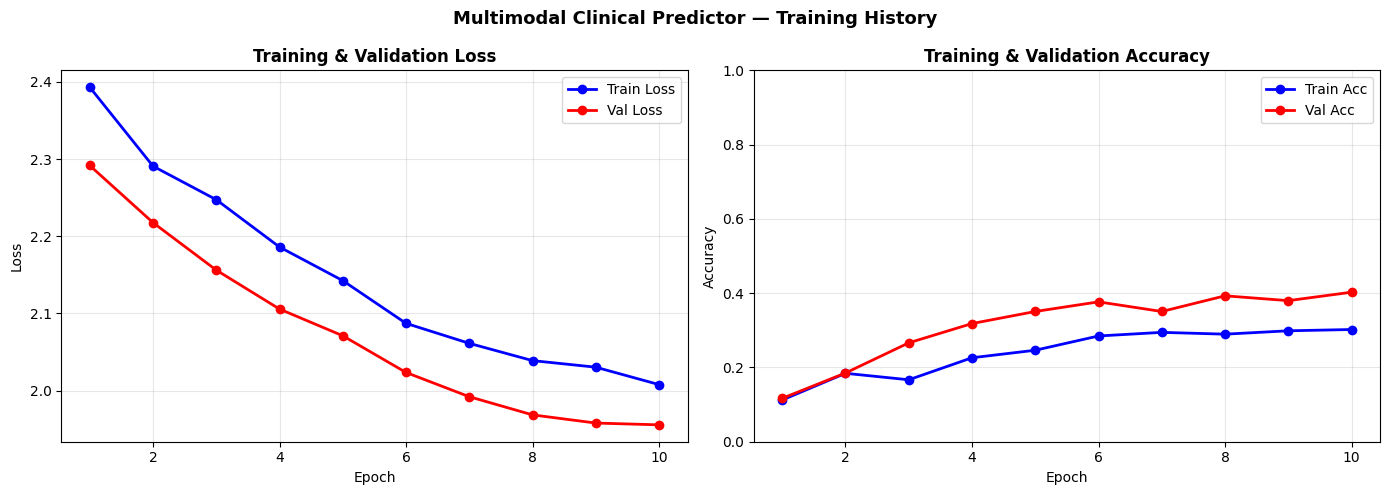

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss curve
axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_ran, history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_ran, history['val_acc'],   'r-o', label='Val Acc',   linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.suptitle('Multimodal Clinical Predictor — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 6️⃣ Test Set Evaluation: Full Metrics Suite

In [7]:
# Load best checkpoint for evaluation
model.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating on test set'):
        images         = batch['image'].to(DEVICE)
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        logits = model(images, input_ids, attention_mask)
        probs  = F.softmax(logits, dim=-1)
        preds  = probs.argmax(dim=-1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# ── Print classification report ─────────────────────────────────────────
print('=== CLASSIFICATION REPORT (Test Set) ===')
print(classification_report(
    all_labels, all_preds,
    target_names=config.CLASS_NAMES,
    digits=4,
))

# ── Additional metrics ──────────────────────────────────────────────────
kappa = cohen_kappa_score(all_labels, all_preds)
mcc   = matthews_corrcoef(all_labels, all_preds)
print(f"Cohen's Kappa:                {kappa:.4f}")
print(f'Matthews Corr. Coefficient:  {mcc:.4f}')

# AUC-ROC (macro OvR)
try:
    auc_score = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    print(f'AUC-ROC (macro OvR):         {auc_score:.4f}')
except Exception as e:
    auc_score = None
    print(f'AUC-ROC: Could not compute ({e})')

Evaluating on test set:   0%|          | 0/39 [00:00<?, ?it/s]

=== CLASSIFICATION REPORT (Test Set) ===
                        precision    recall  f1-score   support

              Neoplasm     0.4750    0.4578    0.4663        83
                Trauma     0.2979    0.7000    0.4179        20
              Vascular     0.5263    0.2857    0.3704        35
            Congenital     0.3548    0.2895    0.3188        38
             Infection     0.4000    0.5714    0.4706        14
          Inflammatory     0.3333    0.1111    0.1667         9
Degenerative/Metabolic     0.5000    0.1667    0.2500         6
Obstruction/Mechanical     0.1724    0.5000    0.2564        10
    Idiopathic/Unknown     0.0909    0.0400    0.0556        25
   Clinical Sign/Other     0.2879    0.2794    0.2836        68

              accuracy                         0.3506       308
             macro avg     0.3439    0.3402    0.3056       308
          weighted avg     0.3651    0.3506    0.3408       308

Cohen's Kappa:                0.2307
Matthews Corr. Coeffici

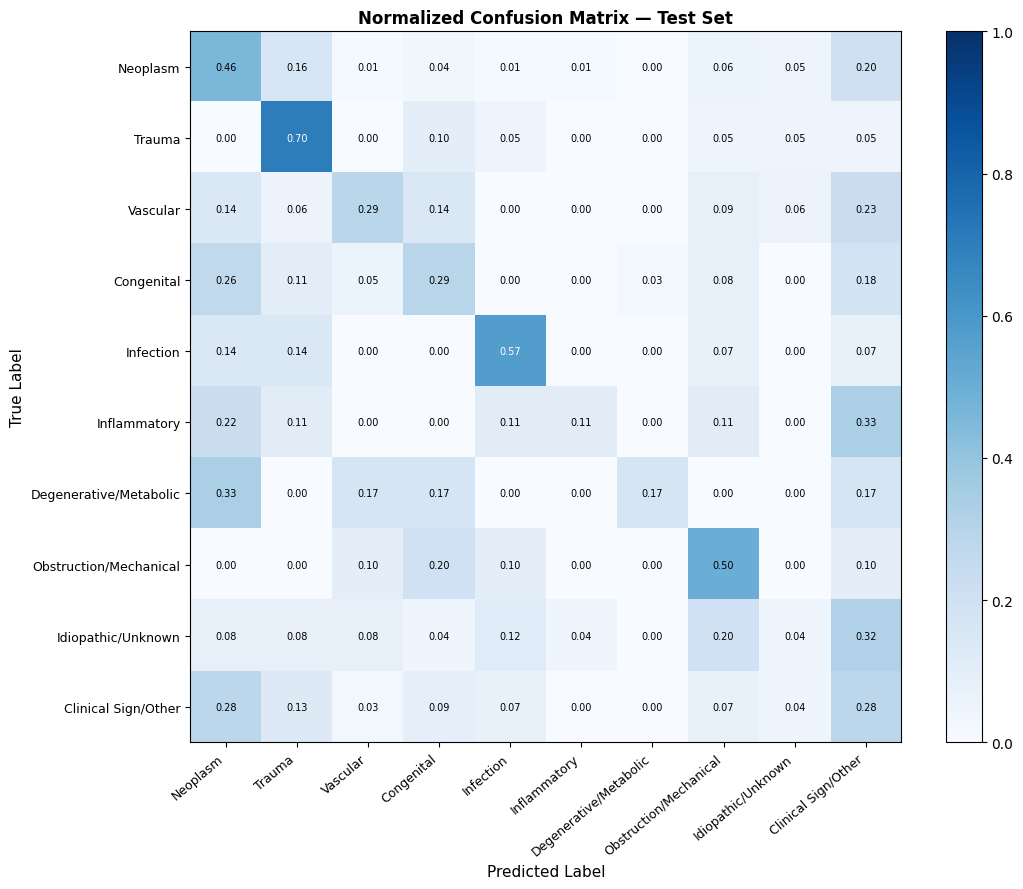

In [8]:
# ── Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds, normalize='true')

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(config.NUM_CLASSES))
ax.set_yticks(range(config.NUM_CLASSES))
ax.set_xticklabels(config.CLASS_NAMES, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(config.CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Normalized Confusion Matrix — Test Set', fontweight='bold', fontsize=12)

for i in range(config.NUM_CLASSES):
    for j in range(config.NUM_CLASSES):
        color = 'white' if cm[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{cm[i, j]:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

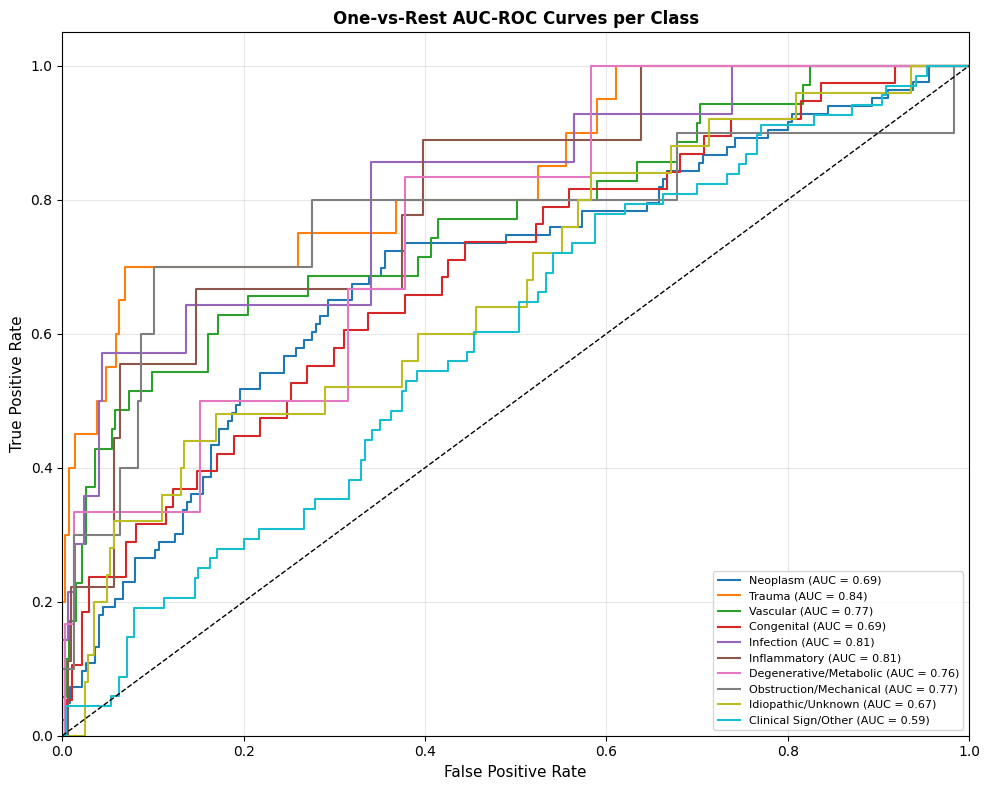

In [9]:
# ── AUC-ROC Curves per class ─────────────────────────────────────────────
from sklearn.preprocessing import label_binarize

y_bin = label_binarize(all_labels, classes=range(config.NUM_CLASSES))

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, config.NUM_CLASSES))

for i, (cls_name, color) in enumerate(zip(config.CLASS_NAMES, colors)):
    try:
        fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=1.5,
                label=f'{cls_name} (AUC = {roc_auc:.2f})')
    except:
        pass

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlim([0.0, 1.0]); ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('One-vs-Rest AUC-ROC Curves per Class', fontweight='bold', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## 7️⃣ Save Evaluation Report

In [10]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

eval_report = {
    'model':          'MultimodalClinicalPredictor (DenseNet121 + BioClinicalBERT)',
    'dataset':        'MedPix',
    'test_samples':   int(len(all_labels)),
    'accuracy':       float(accuracy_score(all_labels, all_preds)),
    'f1_macro':       float(f1_score(all_labels, all_preds, average='macro',    zero_division=0)),
    'f1_weighted':    float(f1_score(all_labels, all_preds, average='weighted', zero_division=0)),
    'precision_macro': float(precision_score(all_labels, all_preds, average='macro',    zero_division=0)),
    'recall_macro':   float(recall_score(all_labels, all_preds, average='macro',    zero_division=0)),
    'auc_roc_macro':  float(auc_score) if auc_score else None,
    'cohen_kappa':    float(kappa),
    'mcc':            float(mcc),
    'class_names':    config.CLASS_NAMES,
    'history':        history,
}

with open(config.EVAL_REPORT_PATH, 'w') as f:
    json.dump(eval_report, f, indent=2)

print('=== EVALUATION SUMMARY ===')
for k, v in eval_report.items():
    if k not in ('history', 'class_names'):
        print(f'  {k:20s}: {v}')

print(f'\n✅ Evaluation report saved to: {config.EVAL_REPORT_PATH}')
print('Proceed to Notebook 04: Explainability (XAI).')

=== EVALUATION SUMMARY ===
  model               : MultimodalClinicalPredictor (DenseNet121 + BioClinicalBERT)
  dataset             : MedPix
  test_samples        : 308
  accuracy            : 0.35064935064935066
  f1_macro            : 0.3056181870032201
  f1_weighted         : 0.34078347171071804
  precision_macro     : 0.3438561844801296
  recall_macro        : 0.34016374091382484
  auc_roc_macro       : 0.7401495270559674
  cohen_kappa         : 0.23066355268580852
  mcc                 : 0.2331267516864755

✅ Evaluation report saved to: Z:\study files\SRM_study\SEM-2\AML-509_Agentic AI and GAN\Team Project\Agent_code_Trial-2\Trial_2\outputs\evaluation_report.json
Proceed to Notebook 04: Explainability (XAI).
